# Data Exploration

**Phase 1 — Data Understanding** (see `PLAN.md`).

Goal: inspect the raw network-flow CSVs before any modeling, and document the
dataset so every later phase shares the same understanding.

This notebook:

1. merges the raw CSVs (reusing `src.data.load.load_and_merge`)
2. inspects shape, columns, and dtypes
3. summarizes the raw `Label` values
4. checks data quality (duplicates, infinities, missing values)
5. quantifies benign-vs-attack class imbalance
6. writes two artifacts:
   - `reports/metrics/dataset_summary.json`
   - `reports/figures/class_distribution.png`

> Read-only exploration: it does **not** modify the raw data or write processed
> splits. Run it top to bottom.

In [ ]:
import sys
from pathlib import Path

# Make the repo root importable whether this runs from notebooks/ or the root.
repo_root = Path.cwd()
if not (repo_root / "src").exists():
    repo_root = repo_root.parent
sys.path.insert(0, str(repo_root))

import json  # noqa: E402

import matplotlib.pyplot as plt  # noqa: E402
import numpy as np  # noqa: E402
import pandas as pd  # noqa: E402

from src.config import settings  # noqa: E402
from src.data.load import load_and_merge  # noqa: E402
from src.features.preprocess import make_binary_label  # noqa: E402

pd.set_option("display.max_columns", 100)
print("repo root:", repo_root)

repo root: /Users/faisalalmashouq/Desktop/Study/CSC429/AI-NIDS


## 1. Load and merge the raw CSVs

`load_and_merge()` reads every CSV under `data/raw/network-intrusion-dataset/` and
concatenates them. The raw column names have leading spaces (e.g. `" Label"`), so
we strip them here — the same normalization `src.data.clean.clean` applies — so
`settings.raw_label_col` (`"Label"`) resolves correctly.

In [2]:
df = load_and_merge()
df.columns = [c.strip() for c in df.columns]
print("Merged shape:", df.shape)
df.head()

Reading: Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv


Reading: Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv


Reading: Friday-WorkingHours-Morning.pcap_ISCX.csv


Reading: Monday-WorkingHours.pcap_ISCX.csv


Reading: Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv


...

Reading: Tuesday-WorkingHours.pcap_ISCX.csv


Reading: Wednesday-workingHours.pcap_ISCX.csv


Merged shape: (2830743, 79)


Merged shape: (2830743, 79)


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Min,Bwd Packet Length Mean,Bwd Packet Length Std,Flow Bytes/s,Flow Packets/s,Flow IAT Mean,Flow IAT Std,Flow IAT Max,Flow IAT Min,Fwd IAT Total,Fwd IAT Mean,Fwd IAT Std,Fwd IAT Max,Fwd IAT Min,Bwd IAT Total,Bwd IAT Mean,Bwd IAT Std,Bwd IAT Max,Bwd IAT Min,Fwd PSH Flags,Bwd PSH Flags,Fwd URG Flags,Bwd URG Flags,Fwd Header Length,Bwd Header Length,Fwd Packets/s,Bwd Packets/s,Min Packet Length,Max Packet Length,Packet Length Mean,Packet Length Std,Packet Length Variance,FIN Flag Count,SYN Flag Count,RST Flag Count,PSH Flag Count,ACK Flag Count,URG Flag Count,CWE Flag Count,ECE Flag Count,Down/Up Ratio,Average Packet Size,Avg Fwd Segment Size,Avg Bwd Segment Size,Fwd Header Length.1,Fwd Avg Bytes/Bulk,Fwd Avg Packets/Bulk,Fwd Avg Bulk Rate,Bwd Avg Bytes/Bulk,Bwd Avg Packets/Bulk,Bwd Avg Bulk Rate,Subflow Fwd Packets,Subflow Fwd Bytes,Subflow Bwd Packets,Subflow Bwd Bytes,Init_Win_bytes_forward,Init_Win_bytes_backward,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,54865,3,2,0,12,0,6,6,6.0,0.0,0,0,0.0,0.0,4.000000e+06,666666.66670,3.0,0.0,3,3,3,3.0,0.0,3,3,0,0.0,0.0,0,0,0,0,0,0,40,0,666666.666700,0.000000,6,6,6.0,0.0,0.0,0,0,0,0,1,0,0,0,0,9.0,6.0,0.0,40,0,0,0,0,0,0,2,12,0,0,33,-1,1,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,55054,109,1,1,6,6,6,6,6.0,0.0,6,6,6.0,0.0,1.100917e+05,18348.62385,109.0,0.0,109,109,0,0.0,0.0,0,0,0,0.0,0.0,0,0,0,0,0,0,20,20,9174.311927,9174.311927,6,6,6.0,0.0,0.0,0,0,0,0,1,1,0,0,1,9.0,6.0,6.0,20,0,0,0,0,0,0,1,6,1,6,29,256,0,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,55055,52,1,1,6,6,6,6,6.0,0.0,6,6,6.0,0.0,2.307692e+05,38461.53846,52.0,0.0,52,52,0,0.0,0.0,0,0,0,0.0,0.0,0,0,0,0,0,0,20,20,19230.769230,19230.769230,6,6,6.0,0.0,0.0,0,0,0,0,1,1,0,0,1,9.0,6.0,6.0,20,0,0,0,0,0,0,1,6,1,6,29,256,0,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,46236,34,1,1,6,6,6,6,6.0,0.0,6,6,6.0,0.0,3.529412e+05,58823.52941,34.0,0.0,34,34,0,0.0,0.0,0,0,0,0.0,0.0,0,0,0,0,0,0,20,20,29411.764710,29411.764710,6,6,6.0,0.0,0.0,0,0,0,0,1,1,0,0,1,9.0,6.0,6.0,20,0,0,0,0,0,0,1,6,1,6,31,329,0,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,54863,3,2,0,12,0,6,6,6.0,0.0,0,0,0.0,0.0,4.000000e+06,666666.66670,3.0,0.0,3,3,3,3.0,0.0,3,3,0,0.0,0.0,0,0,0,0,0,0,40,0,666666.666700,0.000000,6,6,6.0,0.0,0.0,0,0,0,0,1,0,0,0,0,9.0,6.0,0.0,40,0,0,0,0,0,0,2,12,0,0,32,-1,1,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


## 2. Shape, columns, and dtypes

How many rows/columns, and what types are we working with? The dataset is almost
entirely numeric flow features plus the categorical `Label`.

In [3]:
print(f"rows: {len(df):,}")
print(f"columns: {df.shape[1]}")

dtype_counts = df.dtypes.value_counts()
print("\ndtype breakdown:")
print(dtype_counts)

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
non_numeric_cols = [c for c in df.columns if c not in numeric_cols]
print(f"\nnumeric columns: {len(numeric_cols)}")
print(f"non-numeric columns: {non_numeric_cols}")

rows: 2,830,743
columns: 79

dtype breakdown:
int64      54
float64    24
str         1
Name: count, dtype: int64

numeric columns: 78
non-numeric columns: ['Label']


## 3. Raw label distribution

The `Label` column holds the original attack-type names (`BENIGN`, `DDoS`,
`PortScan`, ...). This is what we collapse into the binary target later.

In [4]:
raw_label_col = settings.raw_label_col  # "Label"
df[raw_label_col] = df[raw_label_col].astype(str).str.strip()

label_counts = df[raw_label_col].value_counts()
label_pct = (label_counts / len(df) * 100).round(3)
print(f"{df[raw_label_col].nunique()} distinct labels\n")
pd.DataFrame({"count": label_counts, "percent": label_pct})

15 distinct labels



,count,percent
Label,,
BENIGN,2273097,80.300
DoS Hulk,231073,8.163
PortScan,158930,5.614
DDoS,128027,4.523
DoS GoldenEye,10293,0.364
FTP-Patator,7938,0.280
SSH-Patator,5897,0.208
DoS slowloris,5796,0.205
DoS Slowhttptest,5499,0.194


## 4. Data quality

The CIC-IDS2017 flows are known to contain duplicate rows and `inf` values (from
divide-by-zero rate features). These are what `src.data.clean.clean` removes;
here we just quantify them so the cleaning step is justified and documented.

In [5]:
n_duplicates = int(df.duplicated().sum())

numeric_df = df[numeric_cols]
n_inf = int(np.isinf(numeric_df.to_numpy()).sum())
inf_cols = numeric_df.columns[np.isinf(numeric_df).any()].tolist()

na_per_col = df.isna().sum()
n_missing = int(na_per_col.sum())
missing_cols = na_per_col[na_per_col > 0]

print(f"duplicate rows: {n_duplicates:,} ({n_duplicates / len(df) * 100:.2f}%)")
print(f"infinite values: {n_inf:,} across {len(inf_cols)} column(s)")
print(f"  columns with inf: {inf_cols}")
print(f"missing values: {n_missing:,} across {len(missing_cols)} column(s)")
if len(missing_cols):
    print(missing_cols)

duplicate rows: 308,381 (10.89%)
infinite values: 4,376 across 2 column(s)
  columns with inf: ['Flow Bytes/s', 'Flow Packets/s']
missing values: 1,358 across 1 column(s)
Flow Bytes/s    1358
dtype: int64


## 5. Class imbalance (benign vs attack)

`make_binary_label` maps `BENIGN -> 0` and every attack class `-> 1`. Intrusion
detection is typically imbalanced, and the balance drives which metrics matter
(recall / false-negative rate over raw accuracy).

In [6]:
df = make_binary_label(df)
binary_counts = df[settings.label_col].value_counts().sort_index()

n_benign = int(binary_counts.get(0, 0))
n_attack = int(binary_counts.get(1, 0))
attack_ratio = n_attack / len(df)

print(f"benign (0): {n_benign:,} ({(1 - attack_ratio) * 100:.2f}%)")
print(f"attack (1): {n_attack:,} ({attack_ratio * 100:.2f}%)")
print(f"imbalance ratio (benign : attack) = {n_benign / max(n_attack, 1):.2f} : 1")

benign (0): 2,273,097 (80.30%)
attack (1): 557,646 (19.70%)
imbalance ratio (benign : attack) = 4.08 : 1


## 6. Save the class-distribution figure

A two-panel figure: the binary benign/attack split and the breakdown of attack
types. Saved to `reports/figures/class_distribution.png`.

Saved /Users/faisalalmashouq/Desktop/Study/CSC429/AI-NIDS/reports/figures/class_distribution.png


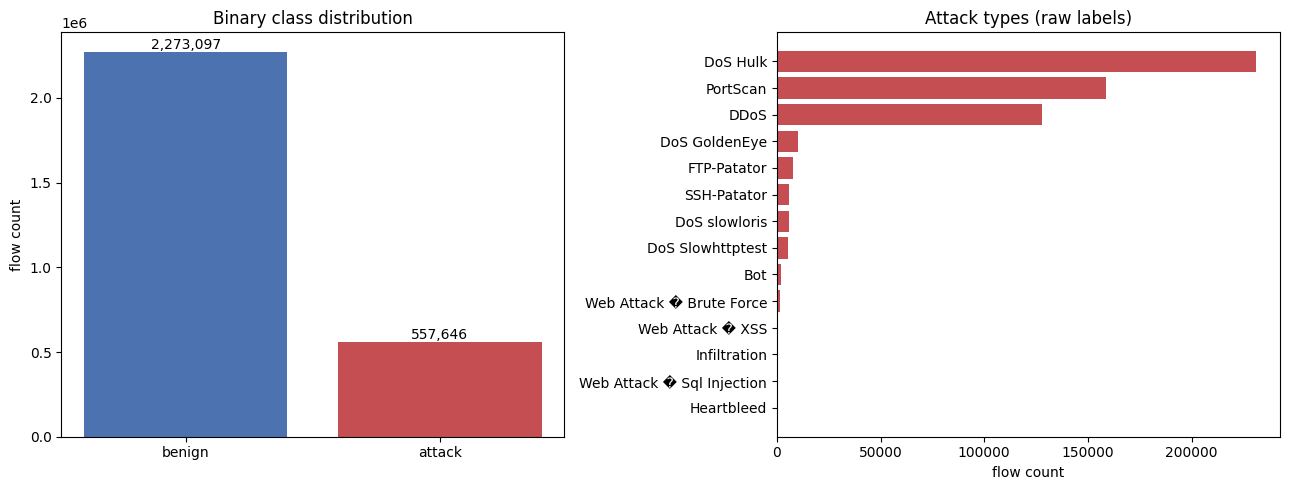

In [7]:
settings.figures_dir.mkdir(parents=True, exist_ok=True)

fig, (ax_bin, ax_attack) = plt.subplots(1, 2, figsize=(13, 5))

# Binary split.
ax_bin.bar(["benign", "attack"], [n_benign, n_attack], color=["#4c72b0", "#c44e52"])
ax_bin.set_title("Binary class distribution")
ax_bin.set_ylabel("flow count")
for i, v in enumerate([n_benign, n_attack]):
    ax_bin.text(i, v, f"{v:,}", ha="center", va="bottom")

# Attack-type breakdown (exclude BENIGN).
attack_labels = label_counts.drop(labels="BENIGN", errors="ignore")
ax_attack.barh(attack_labels.index[::-1], attack_labels.values[::-1], color="#c44e52")
ax_attack.set_title("Attack types (raw labels)")
ax_attack.set_xlabel("flow count")

fig.tight_layout()
fig_path = settings.figures_dir / "class_distribution.png"
fig.savefig(fig_path, dpi=120)
print(f"Saved {fig_path}")
plt.show()

## 7. Save the dataset summary

Persist everything above to `reports/metrics/dataset_summary.json` so later phases
and the final report can reference a single, reproducible snapshot of the raw data.

In [8]:
summary = {
    "n_rows": int(len(df)),
    "n_columns_raw": len(numeric_cols) + len(non_numeric_cols),
    "n_numeric_features": len(numeric_cols),
    "non_numeric_columns": non_numeric_cols,
    "raw_label_distribution": label_counts.to_dict(),
    "binary_label_distribution": {"benign": n_benign, "attack": n_attack},
    "attack_ratio": round(attack_ratio, 6),
    "data_quality": {
        "duplicate_rows": n_duplicates,
        "infinite_values": n_inf,
        "columns_with_inf": inf_cols,
        "missing_values": n_missing,
        "columns_with_missing": missing_cols.index.tolist(),
    },
}

settings.metrics_dir.mkdir(parents=True, exist_ok=True)
summary_path = settings.metrics_dir / "dataset_summary.json"
summary_path.write_text(json.dumps(summary, indent=2))
print(f"Saved {summary_path}\n")
print(json.dumps(summary, indent=2))

Saved /Users/faisalalmashouq/Desktop/Study/CSC429/AI-NIDS/reports/metrics/dataset_summary.json

{
  "n_rows": 2830743,
  "n_columns_raw": 79,
  "n_numeric_features": 78,
  "non_numeric_columns": [
    "Label"
  ],
  "raw_label_distribution": {
    "BENIGN": 2273097,
    "DoS Hulk": 231073,
    "PortScan": 158930,
    "DDoS": 128027,
    "DoS GoldenEye": 10293,
    "FTP-Patator": 7938,
    "SSH-Patator": 5897,
    "DoS slowloris": 5796,
    "DoS Slowhttptest": 5499,
    "Bot": 1966,
    "Web Attack \ufffd Brute Force": 1507,
    "Web Attack \ufffd XSS": 652,
    "Infiltration": 36,
    "Web Attack \ufffd Sql Injection": 21,
    "Heartbleed": 11
  },
  "binary_label_distribution": {
    "benign": 2273097,
    "attack": 557646
  },
  "attack_ratio": 0.196996,
  "data_quality": {
    "duplicate_rows": 308381,
    "infinite_values": 4376,
    "columns_with_inf": [
      "Flow Bytes/s",
      "Flow Packets/s"
    ],
    "missing_values": 1358,
    "columns_with_missing": [
      "Flow Bytes/